# **Diplomado IA: Inteligencia Artificial II - Métodos de Profundización**. <br> Práctico: Meta Aprendizaje (Parte 2)
---
---

**Profesor:** Pablo Messina (pamessina@uc.cl)



# Introducción

Este laboratorio está basado fuertemente en [learn2learn](http://learn2learn.net/examples.vision/), una librería open-source para investigación en meta-learning.

En particular, veremos el uso de dos métodos concretos:

1) Model-Agnostic Meta-Learning (MAML): https://arxiv.org/abs/1703.03400

2) Prototypical Networks for Few-shot Learning: https://arxiv.org/abs/1703.05175

Los datasets que usaremos son Omniglot y Mini-ImageNet, y los códigos consultados para la confección de este laboratorio son los siguientes:

- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_omniglot.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_miniimagenet.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/protonet_miniimagenet.py


# Instalando e importando librerías a usar

Instalamos learn2learn desde GitHub primero debido al siguiente issue: https://github.com/learnables/learn2learn/issues/433

In [ ]:
!git clone https://github.com/learnables/learn2learn.git
%cd learn2learn
!pip install -e .

Cloning into 'learn2learn'...
remote: Enumerating objects: 4878, done.
remote: Counting objects: 100% (1370/1370), done.
remote: Compressing objects: 100% (610/610), done.
remote: Total 4878 (delta 769), reused 1170 (delta 626), pack-reused 3508 (from 1)
Receiving objects: 100% (4878/4878), 9.55 MiB | 13.26 MiB/s, done.
Resolving deltas: 100% (2774/2774), done.
/content/learn2learn
Obtaining file:///content/learn2learn
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 24.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.3/212.3 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━

Luego Colab debería pedirles reinciar el entorno de ejecución. Reinician, e immediatamente después instalan learn2learn con el comando típico !pip install learn2learn:

In [ ]:
!pip install learn2learn

Importamos librerías a usar

In [ ]:
import gc
import random
import numpy as np
import learn2learn as l2l
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch import nn, optim
from typing import List, Tuple
from IPython.display import clear_output

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Usamos cuda

In [ ]:
use_cuda = torch.cuda.is_available() and True
device = torch.device("cuda" if use_cuda else "cpu")
device

device(type='cuda')

# Cargamos datasets: Omniglot y Mini-ImageNet

Funciones para visualizar tareas de ambos datasets

In [ ]:
def visualize_task_omniglot(
    batch: Tuple[torch.Tensor, torch.Tensor], shot: int, ways: int
) -> None:
    """
    Visualize a sampled Omniglot task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 1, H, W), grayscale Omniglot images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shot: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shot * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(adaptation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()


def visualize_task_miniimagenet(
    batch: Tuple[torch.Tensor, torch.Tensor], shots: int, ways: int
) -> None:
    """
    Visualize a sampled Mini-ImageNet task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 3, H, W), RGB Mini-ImageNet images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shots * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        # Permute channels to (H, W, C) and normalize to [0, 1]
        axarr[i].imshow(adaptation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

Definimos WAYS y SHOTS que usaremos

In [ ]:
WAYS = 4
SHOTS = 1

## Cargamos e inspeccionamos Omniglot

In [ ]:
tasksets_omniglot = l2l.vision.benchmarks.get_tasksets('omniglot',
                                                       train_ways=WAYS,
                                                       train_samples=2*SHOTS,
                                                       test_ways=WAYS,
                                                       test_samples=2*SHOTS,
                                                       num_tasks=10000,
                                                       root='~/data',
)

100%|██████████| 9.46M/9.46M [00:00<00:00, 158MB/s]
100%|██████████| 6.46M/6.46M [00:00<00:00, 100MB/s]


Adaptation data:


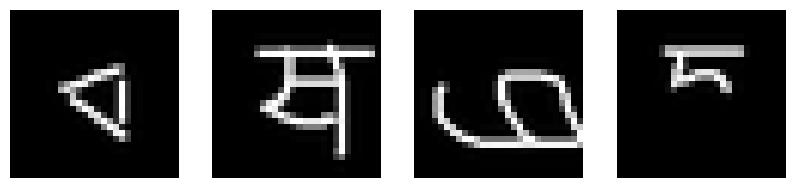

Evaluation data:


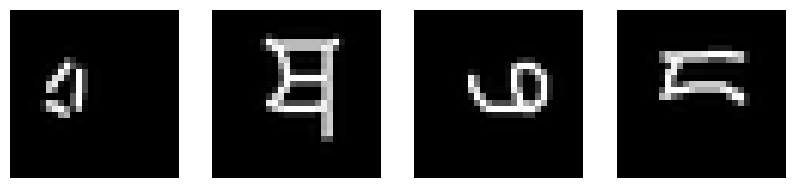

In [ ]:
visualize_task_omniglot(tasksets_omniglot.train.sample(), SHOTS, WAYS)

Adaptation data:


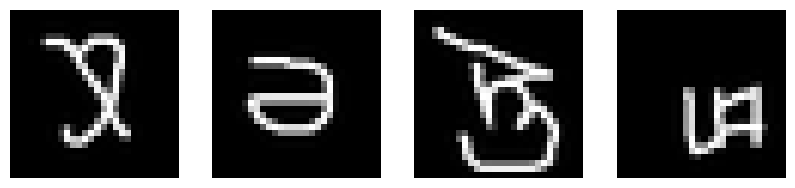

Evaluation data:


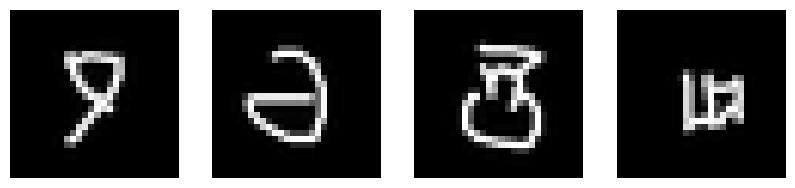

In [ ]:
visualize_task_omniglot(tasksets_omniglot.validation.sample(), SHOTS, WAYS)

Adaptation data:


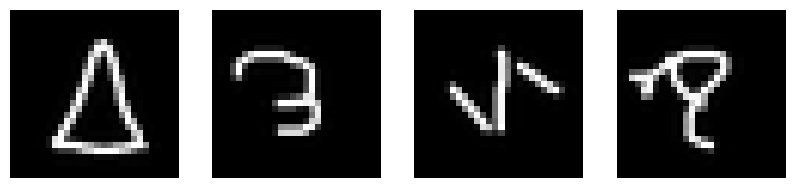

Evaluation data:


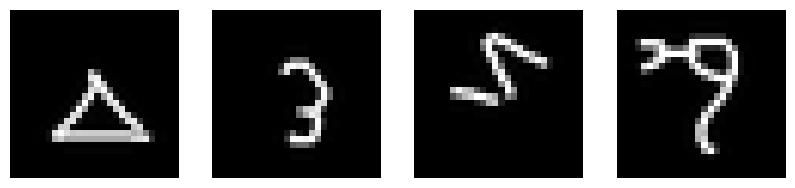

In [ ]:
visualize_task_omniglot(tasksets_omniglot.test.sample(), SHOTS, WAYS)

## Cargamos e inspeccionamos Mini-ImageNet

In [ ]:
# Si la descarga de archivos falla, los siguientes comandos se pueden correr para descargar los archivos manualmente
# !wget -O ~/data/mini-imagenet-cache-validation.pkl https://www.dropbox.com/s/ip1b7se3gij3r1b/mini-imagenet-cache-validation.pkl?dl=1
# !wget -O ~/data/mini-imagenet-cache-train.pkl https://www.dropbox.com/s/9g8c6w345s2ek03/mini-imagenet-cache-train.pkl?dl=1
# !wget -O ~/data/mini-imagenet-cache-test.pkl https://www.dropbox.com/s/ye9jeb5tyz0x01b/mini-imagenet-cache-test.pkl?dl=1

In [ ]:
tasksets_miniimagenet = l2l.vision.benchmarks.get_tasksets('mini-imagenet',
                                                           train_ways=WAYS,
                                                           train_samples=2*SHOTS,
                                                           test_ways=WAYS,
                                                           test_samples=2*SHOTS,
                                                           num_tasks=10000,
                                                           root='~/data',
)

Adaptation data:


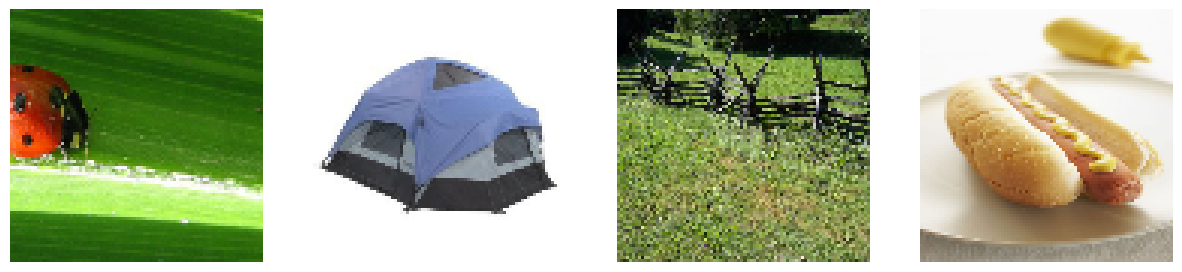

Evaluation data:


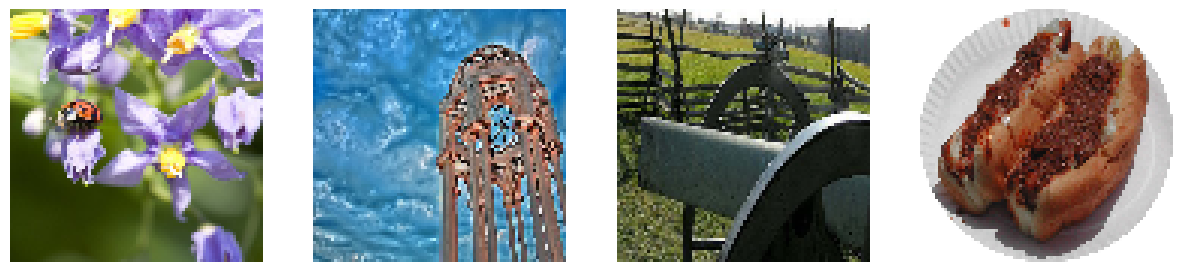

In [ ]:
visualize_task_miniimagenet(tasksets_miniimagenet.train.sample(), SHOTS, WAYS)

Adaptation data:


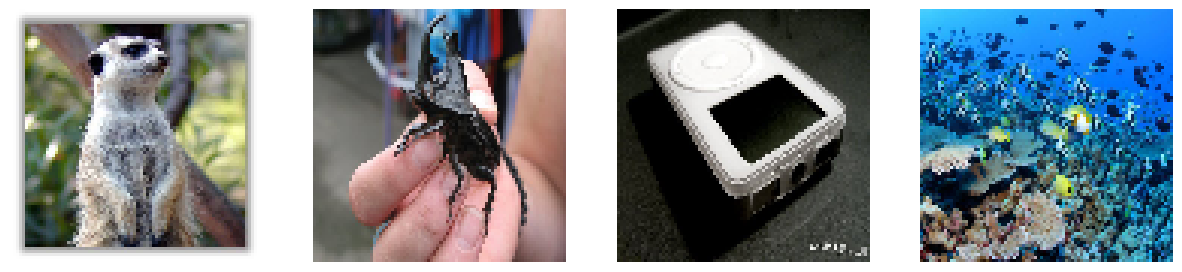

Evaluation data:


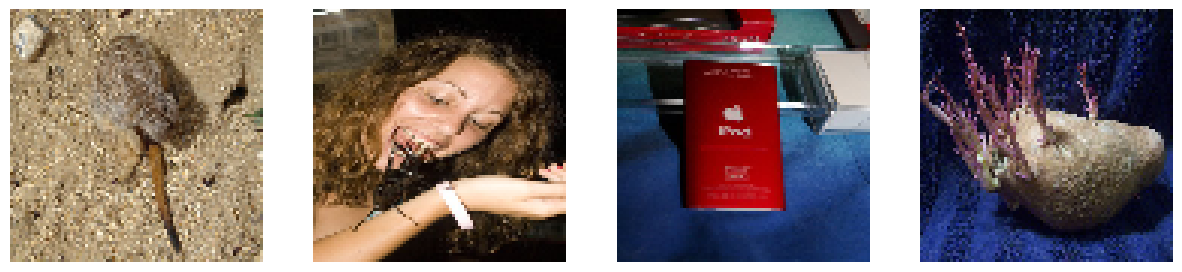

In [ ]:
visualize_task_miniimagenet(tasksets_miniimagenet.validation.sample(), SHOTS, WAYS)

Adaptation data:


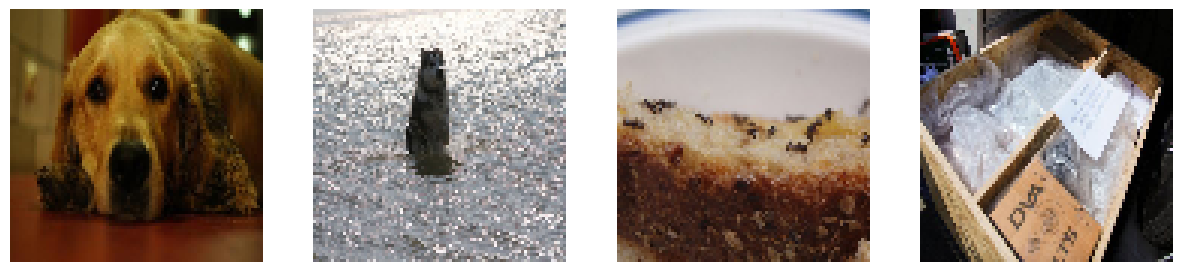

Evaluation data:


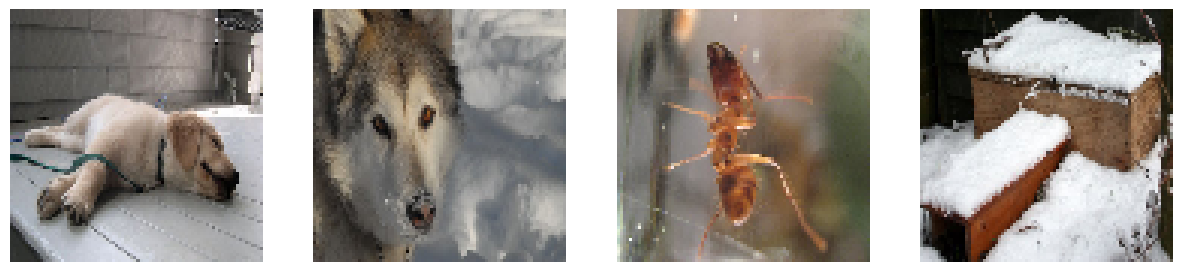

In [ ]:
visualize_task_miniimagenet(tasksets_miniimagenet.test.sample(), SHOTS, WAYS)

**IMPORTANTE**: Borramos tasksets y corremos garbage collection para ahorrar RAM (pueden ver el impacto a la derecha si abren el monitor de recursos)

In [ ]:
del tasksets_omniglot, tasksets_miniimagenet
gc.collect()

70093

# Algunas funciones de utilidad

In [ ]:
def plot_train_valid_curves(
    train_error: List[float],
    train_acc: List[float],
    valid_error: List[float],
    valid_acc: List[float],
    figsize: Tuple[int, int] = (10, 6),
) -> None:
    """
    Plot training and validation error/accuracy curves per epoch.

    Args:
        train_error: List of training error values per epoch.
        train_acc: List of training accuracy values per epoch.
        valid_error: List of validation error values per epoch.
        valid_acc: List of validation accuracy values per epoch.
        figsize: Tuple specifying the figure size (width, height).

    Returns:
        None. Displays the plots using matplotlib.
    """
    plt.figure(figsize=figsize)
    epochs = list(range(1, len(train_error) + 1))

    # Plot error curves
    plt.subplot(121)
    plt.title("Error per epoch")
    plt.plot(epochs, train_error, label="train_error")
    plt.plot(epochs, valid_error, label="valid_error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()

    # Plot accuracy curves
    plt.subplot(122)
    plt.title("Accuracy per epoch")
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, valid_acc, label="valid_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()


def accuracy(predictions: torch.Tensor, targets: torch.Tensor) -> float:
    """
    Compute classification accuracy.

    Args:
        predictions: Model output logits of shape (batch_size, num_classes).
        targets: Ground-truth labels of shape (batch_size,).

    Returns:
        Accuracy as a float in the range [0, 1].
    """
    predicted_labels = predictions.argmax(dim=1).view(targets.shape)
    correct = (predicted_labels == targets).sum().float()
    return (correct / targets.size(0))

# Prototypical Networks for Few-shot Learning

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import learn2learn as l2l
from typing import Callable, Tuple, Optional
from IPython.display import clear_output


def pairwise_distances_logits(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """
    Compute negative squared Euclidean distance between two sets of embeddings.

    Args:
        a: Tensor of shape (N, D), query embeddings.
        b: Tensor of shape (M, D), prototype embeddings.

    Returns:
        logits: Tensor of shape (N, M), where entry (i, j) is the
                negative squared distance between a[i] and b[j].
    """
    n = a.shape[0]
    m = b.shape[0]
    logits = -((a.unsqueeze(1).expand(n, m, -1) -
                b.unsqueeze(0).expand(n, m, -1)) ** 2).sum(dim=2)
    return logits


def fast_adapt_protonet(
    model: torch.nn.Module,
    batch: Tuple[torch.Tensor, torch.Tensor],
    ways: int,
    shots: int,
    metric: Optional[Callable[[torch.Tensor, torch.Tensor], torch.Tensor]] = None,
    device: Optional[torch.device] = None,
) -> Tuple[torch.Tensor, float]:
    """
    Perform fast adaptation for a single task in Prototypical Networks.

    Args:
        model: Embedding model (feature extractor).
        batch: A tuple (data, labels) sampled from the taskset.
        ways: Number of classes per task.
        shots: Number of examples per class for adaptation.
        metric: Distance function (default: pairwise_distances_logits).
        device: Torch device (CPU or CUDA).

    Returns:
        loss: Cross-entropy loss on the query set.
        acc: Accuracy on the query set (float).
    """
    if metric is None:
        metric = pairwise_distances_logits
    if device is None:
        device = next(model.parameters()).device

    data, labels = batch
    data, labels = data.to(device), labels.to(device)

    # Sort data samples by labels (ensures support/query split is consistent)
    sort = torch.sort(labels)
    data = data.squeeze(0)[sort.indices].squeeze(0)
    labels = labels.squeeze(0)[sort.indices].squeeze(0)

    # Compute embeddings
    embeddings = model(data)

    # Split into support and query sets
    support_indices = np.zeros(data.size(0), dtype=bool)
    support_indices[np.arange(shots * ways) * 2] = True
    query_indices = torch.from_numpy(~support_indices)
    support_indices = torch.from_numpy(support_indices)

    support = embeddings[support_indices]
    # Compute class prototypes by averaging support embeddings
    support = support.reshape(ways, shots, -1).mean(dim=1)
    query = embeddings[query_indices]
    labels = labels[query_indices].long()

    # Compute logits, loss, and accuracy
    logits = metric(query, support)
    loss = F.cross_entropy(logits, labels)
    acc = accuracy(logits, labels)

    return loss, acc


def run_Protonet(
    dataset: str,
    model: torch.nn.Module,
    device: torch.device,
    num_epochs: int = 250,
    num_train_tasks_per_epoch: int = 200,
    num_val_tasks_per_epoch: int = 200,
    shots: int = 1,
    ways: int = 5,
    seed: int = 42,
    root: str = "~/data",
) -> None:
    """
    Run Prototypical Networks training, validation, and testing.

    Args:
        dataset: Either 'omniglot' or 'mini-imagenet'.
        model: Embedding model (feature extractor).
        device: Torch device (CPU or CUDA).
        num_epochs: Number of training epochs.
        num_train_tasks_per_epoch: Number of training tasks per epoch.
        num_val_tasks_per_epoch: Number of validation tasks per epoch.
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.
        seed: Random seed for reproducibility.
        root: Path to dataset storage.

    Returns:
        None. Prints metrics and plots training/validation curves.
    """
    # Validate dataset choice
    if dataset not in ["omniglot", "mini-imagenet"]:
        raise ValueError("Dataset must be either 'omniglot' or 'mini-imagenet'.")

    # Set seed
    if torch.cuda.device_count():
        torch.cuda.manual_seed(seed)

    # Construct tasksets inside the function
    tasksets = l2l.vision.benchmarks.get_tasksets(
        dataset,
        train_ways=ways,
        train_samples=2 * shots,
        test_ways=ways,
        test_samples=2 * shots,
        num_tasks=10000,
        root=root,
    )

    # Optimizer and scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    # Error and accuracy lists for training and validation
    train_error, train_acc, valid_error, valid_acc = [], [], [], []

    # BEGIN MAIN LOOP
    for epoch in range(1, num_epochs + 1):  # for each epoch

        # ----- Meta-training -----
        model.train()
        loss_ctr, n_loss, n_acc = 0, 0.0, 0.0

        for task in range(num_train_tasks_per_epoch):
            batch = tasksets.train.sample()
            loss, acc = fast_adapt_protonet(model, batch, ways, shots, device=device)
            loss_ctr += 1
            n_loss += loss.item()
            n_acc += acc.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        lr_scheduler.step()
        meta_train_error = n_loss / loss_ctr
        meta_train_acc = n_acc / loss_ctr

        # ----- Meta-validation -----
        model.eval()
        loss_ctr, n_loss, n_acc = 0, 0.0, 0.0

        for task in range(num_val_tasks_per_epoch):
            batch = tasksets.validation.sample()
            loss, acc = fast_adapt_protonet(model, batch, ways, shots, device=device)
            loss_ctr += 1
            n_loss += loss.item()
            n_acc += acc.item()

        meta_valid_error = n_loss / loss_ctr
        meta_valid_acc = n_acc / loss_ctr

        # Print metrics
        clear_output(True)
        print(f"Epoch {epoch}")
        print("Meta Train Error", meta_train_error)
        print("Meta Train Accuracy", meta_train_acc)
        print("Meta Valid Error", meta_valid_error)
        print("Meta Valid Accuracy", meta_valid_acc)

        train_error.append(meta_train_error)
        train_acc.append(meta_train_acc)
        valid_error.append(meta_valid_error)
        valid_acc.append(meta_valid_acc)

    # END MAIN LOOP

    # Plot training and validation curves
    plot_train_valid_curves(train_error, train_acc, valid_error, valid_acc)

    # ------ Meta-testing ------
    loss_ctr, n_loss, n_acc = 0, 0.0, 0.0
    for i in range(2000):
        batch = tasksets.test.sample()
        loss, acc = fast_adapt_protonet(model, batch, ways, shots, device=device)
        loss_ctr += 1
        n_loss += loss.item()
        n_acc += acc.item()

    print("Meta Test Error", n_loss / loss_ctr)
    print("Meta Test Accuracy", n_acc / loss_ctr)

    # Delete and garbage collect tasksets to save memory
    del tasksets
    gc.collect()

## Prototypical Networks sobre Omniglot

Epoch 40
Meta Train Error 0.7931031738221646
Meta Train Accuracy 0.69875
Meta Valid Error 0.8226454985141755
Meta Valid Accuracy 0.66875


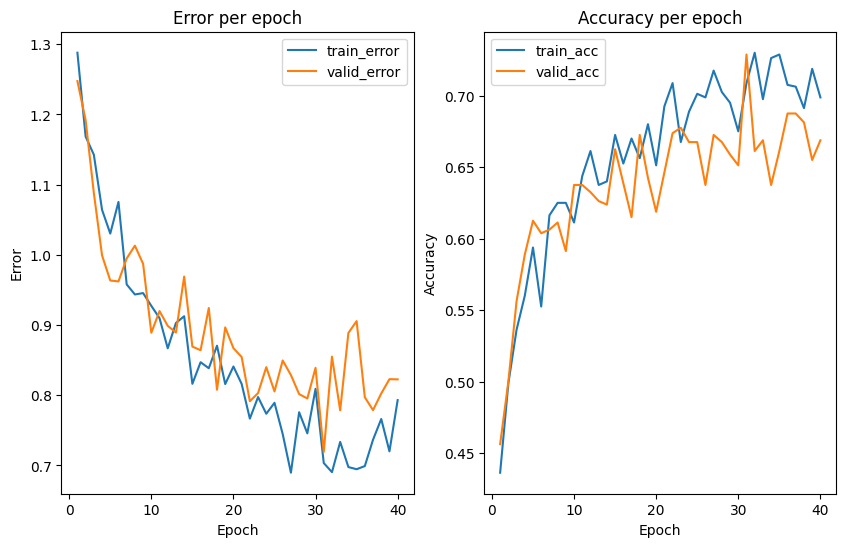

Meta Test Error 0.7755911536216736
Meta Test Accuracy 0.678375


In [ ]:
# Define the model for Omniglot
model = l2l.vision.models.OmniglotFC(28 ** 2, 50) # 50 es la dimensionalidad del embedding
model.to(device)

# Run Prototypical Networks (the dataset is created inside run_Protonet)
run_Protonet(
    dataset="omniglot",
    model=model,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,
)

### Actividad 4

¿Mejorarán los resultados de Prototype Networts en omniglot si se reemplaza `model = l2l.vision.models.OmniglotFC(28 ** 2, 50)` con algún otro modelo o variante más sofisticada?

Puede definir su propio modelo o buscar algún modelo en l2l.vision.models (aquí hay documentación: http://learn2learn.net/docs/learn2learn.vision/#learn2learnvisionmodels)

In [ ]:
# Su código acá, puede agregar más celdas si lo desea

Comente sus resultados acá (**doble click para editar**)

### Actividad 5

Usando el mejor modelo que logró encontar en la Actividad 4:

* ¿cómo varían los resultados si modifica el hiperparámetro WAYS?

* ¿cómo varían los resultados si modifica el hiperparámetro SHOTS?

A continuación se deja un código comentado de referencia ilustrando cómo se deben modificar WAYS y SHOTS. Nótese que debemos redefinir el dataset para que el sampleo de datos sea consistente con los nuevos valores de WAYS y SHOTS que vamos a usar.

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.

In [ ]:
# Su código acá, puede agregar más celdas si lo desea.

# Abajo un ejemplo ilustrativo de cómo se pueden modificar SHOTS y WAYS.
# Nota: ya no es necesario redefinir manualmente el dataset,
# porque run_Protonet lo construye internamente usando SHOTS y WAYS.

WAYS = # algún valor
SHOTS = # algún valor

# Definir el modelo
# IMPORTANTE: aquí debe ir el mejor modelo que usted haya encontrado
# en la actividad previa (no se especifica un modelo concreto).
model = # su mejor modelo de la actividad anterior
model.to(device)

# Ejecutar Prototypical Networks (el dataset se crea dentro de run_Protonet)
run_Protonet(
    dataset="omniglot",   # o "mini-imagenet"
    model=model,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,  # Nota: si desea entrenar por más épocas, puede cambiar este valor
)

Comente sus resultados acá (**doble click para editar**)

## Prototypical Networks sobre Mini-ImageNet

Epoch 40
Meta Train Error 1.2940664601325989
Meta Train Accuracy 0.41625
Meta Valid Error 1.3413218706846237
Meta Valid Accuracy 0.3775


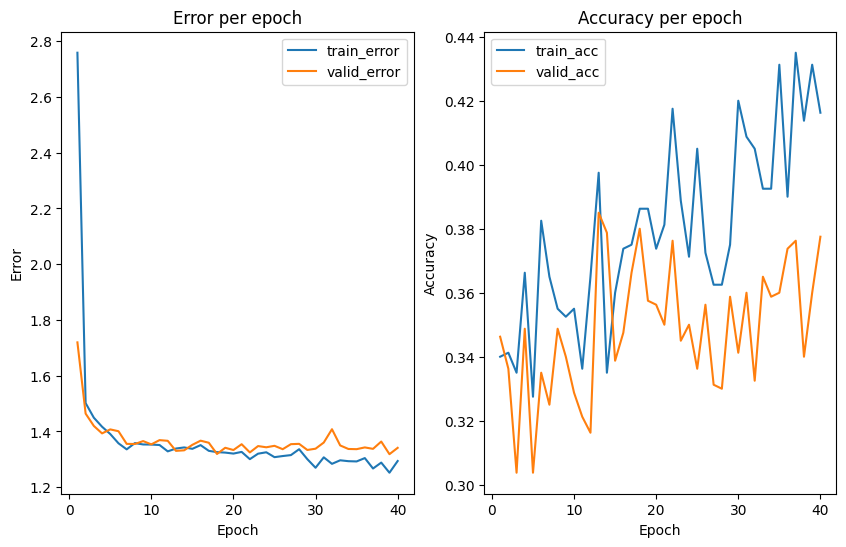

Meta Test Error 1.3758558048903942
Meta Test Accuracy 0.358


In [ ]:
model = l2l.vision.models.MiniImagenetCNN(50)
model.to(device)

run_Protonet(
    dataset="mini-imagenet",
    model=model,
    device=device,
    shots=SHOTS,
    ways=WAYS,
    num_epochs=40,
)

### Actividad 6

Los resultados con Prototype Networks nos confirman nuevamente que mini-imagenet es más complicado que omniglot.

1. ¿Mejorarán los resultados si es que aumentamos el hiperparámetro SHOTS?
2. ¿Mejorarán los resultados si es que disminuímos el hiperparámetro WAYS?
3. ¿Mejorarán los resultados con una versión distinta de CNN (más capas, otra arquitectura, etc.)?

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y/o SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.




In [ ]:
# Su código acá, puede agregar más celdas si lo desea

Comente sus resultados acá (**doble click para editar**)

### Actividad 7
Preguntas teóricas

1) Recordemos que MAML es un método de meta-aprendizaje basado en optimización, que a simple vista se ve muy parecido al fine-tuning tradicional. Sin embargo, hay una diferencia clave en cómo se realiza la optimización durante el meta-entrenamiento que los hace distintos.
- ¿Cuál es esa diferencia?
- ¿Qué beneficios le trae dicha diferencia a MAML por sobre el fine-tuning tradicional y por qué?

**Respuesta**: (doble click para editar)

2) En la clase vimos 3 metódos de meta-aprendizaje no-parametrizados: Redes Siamesas, Matching Networks y Prototype Networks. El segundo método propone mejoras sobre el primero y el tercero mejoras sobre el segundo.

A grandes rasgos:
- ¿En qué consiste cada método?
- ¿Qué mejora(s) proponen Matching Networks con respecto a Redes Siamesas?
- ¿Qué mejora(s) proponen Prototype Networks con respecto a Matching Networks?

**Respuesta**: (doble click para editar)